In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv('../outputs/01_datos_limpios.csv')
specs = pd.read_csv('../data/num_parte_hijo_consignatario.csv')

# Asegurar tipos correctos
df['FECHA_ARMADO_DIA'] = pd.to_datetime(df['FECHA_ARMADO_DIA']).dt.date
df['PESO_NETO_DESP'] = pd.to_numeric(df['PESO_NETO_DESP'], errors='coerce')
df['D_EXTERNO'] = pd.to_numeric(df['D_EXTERNO'], errors='coerce')
df['ANCHO_HIJO'] = pd.to_numeric(df['ANCHO_HIJO'], errors='coerce')

print(f"Cintas cargadas: {len(df):,}")
print(f"Fechas únicas: {df['FECHA_ARMADO_DIA'].nunique():,}")
print(f"Combinaciones en especificaciones: {len(specs):,}")

Cintas cargadas: 27,794
Fechas únicas: 321
Combinaciones en especificaciones: 798


In [14]:
# Unir especificaciones al DataFrame principal
df = df.merge(
    specs[['NUMERO_PARTE_HIJO', 'CONSIGNATARIO',
           'Discos_maximos_definidos', 'Peso_maximo_definido']],
    on=['NUMERO_PARTE_HIJO', 'CONSIGNATARIO'],
    how='left'
)

# Calcular medianas del histórico como fallback para combinaciones sin especificación
mediana_discos = df['Discos_maximos_definidos'].median()
mediana_peso = df['Peso_maximo_definido'].median()

df['Discos_maximos_definidos'] = df['Discos_maximos_definidos'].fillna(mediana_discos)
df['Peso_maximo_definido'] = df['Peso_maximo_definido'].fillna(mediana_peso)

print(f"Fallback discos (mediana): {mediana_discos}")
print(f"Fallback peso (mediana): {mediana_peso:.4f}")
print(f"Cintas sin match en especificaciones: {df['Discos_maximos_definidos'].isna().sum()}")

Fallback discos (mediana): 3.0
Fallback peso (mediana): 7.2960
Cintas sin match en especificaciones: 0


In [15]:
# Verificar duplicados después del merge
print(f"Filas antes del merge: (verificar vs carga inicial)")
print(f"Filas después del merge: {len(df):,}")
print(f"\nDuplicados en índice: {df.index.duplicated().sum()}")
print(f"Duplicados en ARMA_TARIMA + NUMERO_PARTE_HIJO: {df.duplicated(subset=['ARMA_TARIMA','NUMERO_PARTE_HIJO']).sum()}")

# Verificar si specs tiene duplicados por NUMERO_PARTE_HIJO + CONSIGNATARIO
print(f"\nDuplicados en specs por clave de merge: {specs.duplicated(subset=['NUMERO_PARTE_HIJO','CONSIGNATARIO']).sum()}")
print(f"Filas en specs: {len(specs):,}")

Filas antes del merge: (verificar vs carga inicial)
Filas después del merge: 27,794

Duplicados en índice: 0
Duplicados en ARMA_TARIMA + NUMERO_PARTE_HIJO: 17694

Duplicados en specs por clave de merge: 0
Filas en specs: 798


In [16]:
def armar_tarimas(cintas_dia):
    """
    Recibe un DataFrame con las cintas disponibles en un día.
    Retorna una lista de tarimas, donde cada tarima es una lista de índices del DataFrame original.
    """
    # Ordenar por CONSIGNATARIO, MATERIAL_PADRE, NUMERO_PARTE_HIJO y PESO_NETO_DESP descendente
    cintas_dia = cintas_dia.sort_values(
        by=['CONSIGNATARIO', 'MATERIAL_PADRE', 'NUMERO_PARTE_HIJO', 'PESO_NETO_DESP'],
        ascending=[True, True, True, False]
    )

    tarimas = []  # Lista de tarimas abiertas; cada tarima es una lista de índices

    for idx, cinta in cintas_dia.iterrows():

        agregada = False

        for tarima in tarimas:
            cintas_en_tarima = cintas_dia.loc[tarima]

            # Restricción 1 — Mismo CONSIGNATARIO
            if cinta['CONSIGNATARIO'] != cintas_en_tarima['CONSIGNATARIO'].iloc[0]:
                continue

            # Restricción 2 — Mismo MATERIAL_PADRE
            if cinta['MATERIAL_PADRE'] != cintas_en_tarima['MATERIAL_PADRE'].iloc[0]:
                continue

            # Restricción 3 — Mismo TIPO_EMBALAJE
            if cinta['TIPO_EMBALAJE'] != cintas_en_tarima['TIPO_EMBALAJE'].iloc[0]:
                continue

            # Restricción 4 — Diferencia de D_EXTERNO <= 76.2 mm
            d_externos = list(cintas_en_tarima['D_EXTERNO']) + [cinta['D_EXTERNO']]
            if max(d_externos) - min(d_externos) > 76.2:
                continue

            # Restricción 5 — No superar Discos_maximos_definidos
            # Usar el mínimo entre las cintas ya en la tarima y la candidata
            discos_max = min(
                cintas_en_tarima['Discos_maximos_definidos'].min(),
                cinta['Discos_maximos_definidos']
            )
            if len(tarima) + 1 > discos_max:
                continue

            # Restricción 6 — No superar Peso_maximo_definido
            # Usar el mínimo entre las cintas ya en la tarima y la candidata
            peso_max = min(
                cintas_en_tarima['Peso_maximo_definido'].min(),
                cinta['Peso_maximo_definido']
            )
            peso_acumulado = cintas_en_tarima['PESO_NETO_DESP'].sum()
            if peso_acumulado + cinta['PESO_NETO_DESP'] > peso_max:
                continue

            # Restricción 7 — Si OJO_HORIZONTAL: ANCHO_HIJO <= 1500 mm
            if cinta['TIPO_EMBALAJE'] == 'OJO_HORIZONTAL':
                if cinta['ANCHO_HIJO'] > 1500:
                    continue

            # Si pasa todas las restricciones, agregar a esta tarima
            tarima.append(idx)
            agregada = True
            break

        # Si no cabe en ninguna tarima existente, abrir una nueva
        if not agregada:
            tarimas.append([idx])

    return tarimas

In [17]:
resultados_cintas = []
resultados_tarimas = []
contador_tarima = 0

fechas = sorted(df['FECHA_ARMADO_DIA'].unique())
print(f"Procesando {len(fechas):,} fechas...")

for fecha in fechas:
    grupo_fecha = df[df['FECHA_ARMADO_DIA'] == fecha]
    tarimas = armar_tarimas(grupo_fecha)

    for tarima in tarimas:
        contador_tarima += 1
        id_tarima = f"PROP_{contador_tarima:06d}"

        for idx in tarima:
            fila = df.loc[idx].copy()
            fila['TARIMA_PROPUESTA'] = id_tarima
            resultados_cintas.append(fila)

        cintas_tarima = df.loc[tarima]
        resultados_tarimas.append({
            'TARIMA_PROPUESTA': id_tarima,
            'FECHA_ARMADO_DIA': fecha,
            'CONSIGNATARIO': cintas_tarima['CONSIGNATARIO'].iloc[0],
            'MATERIAL_PADRE': cintas_tarima['MATERIAL_PADRE'].iloc[0],
            'NUMERO_PARTE_HIJO': cintas_tarima['NUMERO_PARTE_HIJO'].mode()[0],
            'TIPO_EMBALAJE': cintas_tarima['TIPO_EMBALAJE'].iloc[0],
            'n_cintas': len(tarima),
            'peso_total': round(cintas_tarima['PESO_NETO_DESP'].sum(), 4),
            'Discos_maximos_definidos': cintas_tarima['Discos_maximos_definidos'].min(),
            'Peso_maximo_definido': cintas_tarima['Peso_maximo_definido'].min(),
        })

df_cintas = pd.DataFrame(resultados_cintas)
df_tarimas = pd.DataFrame(resultados_tarimas)

print(f"Cintas asignadas: {len(df_cintas):,}")
print(f"Tarimas propuestas: {len(df_tarimas):,}")

Procesando 321 fechas...
Cintas asignadas: 27,794
Tarimas propuestas: 10,166


Se comienza a probar el heuristico probando la unicidad del índice 

In [18]:
# Verificar unicidad del índice antes de correr la heurística
print(f"Índice único en df: {df.index.is_unique}")
print(f"Tipo de índice: {df.index.dtype}")

# Forzar índice único basado en posición
df = df.reset_index(drop=True)
print(f"Índice único después de reset: {df.index.is_unique}")

# Verificar con una fecha ejemplo
fecha_ejemplo = df['FECHA_ARMADO_DIA'].iloc[0]
grupo_ejemplo = df[df['FECHA_ARMADO_DIA'] == fecha_ejemplo]
print(f"\nFecha ejemplo: {fecha_ejemplo}")
print(f"Cintas en esa fecha: {len(grupo_ejemplo)}")
print(f"Índice único en grupo: {grupo_ejemplo.index.is_unique}")
print(f"Rango de índices: {grupo_ejemplo.index.min()} a {grupo_ejemplo.index.max()}")

Índice único en df: True
Tipo de índice: int64
Índice único después de reset: True

Fecha ejemplo: 2025-04-26
Cintas en esa fecha: 66
Índice único en grupo: True
Rango de índices: 0 a 26544


Verificar tarimas que violan las normas. Vemos que las únicas tarimas que las violan son aquellas que contienen unicamente una cinta pero muy pesada (se deja pasar porque estas cintas requieren una tarima)

In [19]:
# Identificar tarimas que violan restricciones
violaciones_peso = df_tarimas[df_tarimas['peso_total'] > df_tarimas['Peso_maximo_definido']]
violaciones_discos = df_tarimas[df_tarimas['n_cintas'] > df_tarimas['Discos_maximos_definidos']]

print(f"Tarimas que violan Peso_maximo_definido: {len(violaciones_peso)}")
print(f"Tarimas que violan Discos_maximos_definidos: {len(violaciones_discos)}")

print(f"\nEjemplos de violaciones de peso:")
print(violaciones_peso[['TARIMA_PROPUESTA', 'n_cintas', 'peso_total', 
                          'Peso_maximo_definido', 'NUMERO_PARTE_HIJO', 
                          'CONSIGNATARIO']].head(5).to_string())

print(f"\nEjemplos de violaciones de discos:")
print(violaciones_discos[['TARIMA_PROPUESTA', 'n_cintas', 'peso_total',
                            'Discos_maximos_definidos', 'NUMERO_PARTE_HIJO',
                            'CONSIGNATARIO']].head(5).to_string())

# Para una tarima violadora específica, ver las cintas que la componen
if len(violaciones_peso) > 0:
    tarima_ejemplo = violaciones_peso['TARIMA_PROPUESTA'].iloc[0]
    cintas_ejemplo = df_cintas[df_cintas['TARIMA_PROPUESTA'] == tarima_ejemplo]
    print(f"\nCintas de la tarima violadora {tarima_ejemplo}:")
    print(cintas_ejemplo[['NUMERO_PARTE_HIJO', 'CONSIGNATARIO', 'PESO_NETO_DESP',
                            'Peso_maximo_definido', 'Discos_maximos_definidos']].to_string())

Tarimas que violan Peso_maximo_definido: 47
Tarimas que violan Discos_maximos_definidos: 0

Ejemplos de violaciones de peso:
    TARIMA_PROPUESTA  n_cintas  peso_total  Peso_maximo_definido    NUMERO_PARTE_HIJO CONSIGNATARIO
66       PROP_000067         1       7.938                 7.296              5500074    N000110899
187      PROP_000188         1       2.308                 2.303             2034298F    N000110899
221      PROP_000222         1       1.630                 1.620  POLIN NGO C COM C12    N000110899
222      PROP_000223         1       1.830                 1.620  POLIN NGO C COM C12    N000110899
223      PROP_000224         1       1.850                 1.620  POLIN NGO C COM C12    N000110899

Ejemplos de violaciones de discos:
Empty DataFrame
Columns: [TARIMA_PROPUESTA, n_cintas, peso_total, Discos_maximos_definidos, NUMERO_PARTE_HIJO, CONSIGNATARIO]
Index: []

Cintas de la tarima violadora PROP_000067:
      NUMERO_PARTE_HIJO CONSIGNATARIO  PESO_NETO_DESP  Peso

verificar cintas que violan

In [20]:
# Verificar si hay variación de especificaciones dentro de tarimas violadoras
tarima_ejemplo = 'PROP_000334'
cintas_ejemplo = df_cintas[df_cintas['TARIMA_PROPUESTA'] == tarima_ejemplo]
print(f"Cintas de {tarima_ejemplo}:")
print(cintas_ejemplo[['NUMERO_PARTE_HIJO', 'CONSIGNATARIO', 'PESO_NETO_DESP',
                        'Peso_maximo_definido', 'Discos_maximos_definidos']].to_string())

Cintas de PROP_000334:
     NUMERO_PARTE_HIJO CONSIGNATARIO  PESO_NETO_DESP  Peso_maximo_definido  Discos_maximos_definidos
3977          180597AA    N000110575           3.665                11.058                       3.0
3978          180597AA    N000110575           3.535                11.058                       3.0


Se guardan los resultados

In [21]:
df_cintas.to_csv('../outputs/heuristica_cintas.csv', index=False)
df_tarimas.to_csv('../outputs/heuristica_tarimas.csv', index=False)

print("Archivos guardados:")
print("  outputs/heuristica_cintas.csv")
print("  outputs/heuristica_tarimas.csv")
print(f"\nEstadísticas de tarimas propuestas:")
print(df_tarimas[['n_cintas', 'peso_total', 'Discos_maximos_definidos', 'Peso_maximo_definido']].describe().round(3))

Archivos guardados:
  outputs/heuristica_cintas.csv
  outputs/heuristica_tarimas.csv

Estadísticas de tarimas propuestas:
        n_cintas  peso_total  Discos_maximos_definidos  Peso_maximo_definido
count  10166.000   10166.000                 10166.000             10166.000
mean       2.734       6.586                     4.146                 9.029
std        1.612       5.557                    13.951                11.537
min        1.000       0.124                     1.000                 0.832
25%        2.000       2.375                     2.000                 3.342
50%        2.000       4.030                     3.000                 6.738
75%        3.000       9.430                     4.000                14.286
max       17.000      24.975                   500.000               374.000


Comparamos los resultados de las tarimas generadas por el heuristico y las reales

In [23]:
# Tarimas reales en el histórico
tarimas_reales = df.groupby('ARMA_TARIMA').agg(
    n_cintas_real=('PESO_NETO_DESP', 'count'),
    peso_total_real=('PESO_NETO_DESP', 'sum')
).reset_index()

print("=== COMPARACIÓN: Heurística vs Histórico Real ===\n")

print(f"Número de tarimas:")
print(f"  Histórico real:      {len(tarimas_reales):,}")
print(f"  Heurística propone:  {len(df_tarimas):,}")
reduccion = (len(tarimas_reales) - len(df_tarimas)) / len(tarimas_reales) * 100
print(f"  Reducción:           {reduccion:.1f}%")

print(f"\nPeso promedio por tarima (toneladas):")
print(f"  Histórico real:      {tarimas_reales['peso_total_real'].mean():.4f}")
print(f"  Heurística propone:  {df_tarimas['peso_total'].mean():.4f}")

print(f"\nCintas promedio por tarima:")
print(f"  Histórico real:      {tarimas_reales['n_cintas_real'].mean():.2f}")
print(f"  Heurística propone:  {df_tarimas['n_cintas'].mean():.2f}")

print(f"\nUso del límite de peso (peso_total / Peso_maximo_definido):")
df_tarimas['uso_peso'] = df_tarimas['peso_total'] / df_tarimas['Peso_maximo_definido']
print(df_tarimas['uso_peso'].describe().round(3))

print(f"\nUso del límite de cintas (n_cintas / Discos_maximos_definidos):")
df_tarimas['uso_discos'] = df_tarimas['n_cintas'] / df_tarimas['Discos_maximos_definidos']
print(df_tarimas['uso_discos'].describe().round(3))

=== COMPARACIÓN: Heurística vs Histórico Real ===

Número de tarimas:
  Histórico real:      9,817
  Heurística propone:  10,166
  Reducción:           -3.6%

Peso promedio por tarima (toneladas):
  Histórico real:      6.8199
  Heurística propone:  6.5858

Cintas promedio por tarima:
  Histórico real:      2.83
  Heurística propone:  2.73

Uso del límite de peso (peso_total / Peso_maximo_definido):
count    10166.000
mean         0.767
std          0.225
min          0.004
25%          0.628
50%          0.846
75%          0.952
max          1.316
Name: uso_peso, dtype: float64

Uso del límite de cintas (n_cintas / Discos_maximos_definidos):
count    10166.000
mean         0.859
std          0.229
min          0.004
25%          0.667
50%          1.000
75%          1.000
max          1.000
Name: uso_discos, dtype: float64


In [24]:
# ¿Cuántas tarimas reales se desarmaron?
desarmes_reales = df.groupby('ARMA_TARIMA')['DESARMA_TARIMA'].max()
print(f"Tarimas reales desarmadas: {desarmes_reales.sum():,} ({desarmes_reales.mean()*100:.1f}%)")
print(f"Tarimas reales NO desarmadas: {(desarmes_reales==0).sum():,}")

# Comparar heurística solo contra tarimas reales válidas (no desarmadas)
tarimas_validas_reales = (desarmes_reales == 0).sum()
print(f"\nComparación ajustada:")
print(f"  Tarimas reales válidas (no desarmadas): {tarimas_validas_reales:,}")
print(f"  Heurística propone:                     {len(df_tarimas):,}")
reduccion_ajustada = (tarimas_validas_reales - len(df_tarimas)) / tarimas_validas_reales * 100
print(f"  Diferencia vs tarimas válidas:          {reduccion_ajustada:.1f}%")

# Peso promedio en tarimas reales válidas vs desarmadas
peso_por_tarima_real = df.groupby('ARMA_TARIMA').agg(
    peso_total=('PESO_NETO_DESP', 'sum'),
    desarme=('DESARMA_TARIMA', 'max')
)
print(f"\nPeso promedio tarimas reales NO desarmadas: {peso_por_tarima_real[peso_por_tarima_real['desarme']==0]['peso_total'].mean():.4f} ton")
print(f"Peso promedio tarimas reales desarmadas:    {peso_por_tarima_real[peso_por_tarima_real['desarme']==1]['peso_total'].mean():.4f} ton")
print(f"Peso promedio heurística:                   {df_tarimas['peso_total'].mean():.4f} ton")

Tarimas reales desarmadas: 2,029 (20.7%)
Tarimas reales NO desarmadas: 7,788

Comparación ajustada:
  Tarimas reales válidas (no desarmadas): 7,788
  Heurística propone:                     10,166
  Diferencia vs tarimas válidas:          -30.5%

Peso promedio tarimas reales NO desarmadas: 6.1265 ton
Peso promedio tarimas reales desarmadas:    9.4814 ton
Peso promedio heurística:                   6.5858 ton


In [25]:
# ¿Cuántas tarimas desarmadas hubiera evitado la heurística?
# Lógica: una tarima real desarmada se hubiera evitado si violaba al menos una 
# de las restricciones que la heurística respeta.

# Reconstruir métricas por tarima real
tarimas_reales_detalle = df.groupby('ARMA_TARIMA').agg(
    n_cintas=('PESO_NETO_DESP', 'count'),
    peso_total=('PESO_NETO_DESP', 'sum'),
    n_materiales_padre=('MATERIAL_PADRE', 'nunique'),
    n_consignatarios=('CONSIGNATARIO', 'nunique'),
    diff_diametro=('D_EXTERNO', lambda x: x.max() - x.min()),
    n_tipos_embalaje=('TIPO_EMBALAJE', 'nunique'),
    ancho_max=('ANCHO_HIJO', 'max'),
    peso_max_definido=('Peso_maximo_definido', 'min'),
    discos_max_definidos=('Discos_maximos_definidos', 'min'),
    desarme=('DESARMA_TARIMA', 'max')
).reset_index()

# Identificar qué restricción violaba cada tarima desarmada
tarimas_desarmadas = tarimas_reales_detalle[tarimas_reales_detalle['desarme'] == 1].copy()

tarimas_desarmadas['viola_peso']         = tarimas_desarmadas['peso_total'] > tarimas_desarmadas['peso_max_definido']
tarimas_desarmadas['viola_discos']       = tarimas_desarmadas['n_cintas'] > tarimas_desarmadas['discos_max_definidos']
tarimas_desarmadas['viola_multi_padre']  = tarimas_desarmadas['n_materiales_padre'] > 1
tarimas_desarmadas['viola_multi_consig'] = tarimas_desarmadas['n_consignatarios'] > 1
tarimas_desarmadas['viola_diametro']     = tarimas_desarmadas['diff_diametro'] > 76.2
tarimas_desarmadas['viola_embalaje']     = tarimas_desarmadas['n_tipos_embalaje'] > 1
tarimas_desarmadas['viola_ancho']        = (
    (tarimas_desarmadas['ancho_max'] > 1500)
)

tarimas_desarmadas['viola_alguna'] = (
    tarimas_desarmadas['viola_peso'] |
    tarimas_desarmadas['viola_discos'] |
    tarimas_desarmadas['viola_multi_padre'] |
    tarimas_desarmadas['viola_multi_consig'] |
    tarimas_desarmadas['viola_diametro'] |
    tarimas_desarmadas['viola_embalaje'] |
    tarimas_desarmadas['viola_ancho']
)

print("=== DESARMES QUE LA HEURÍSTICA HUBIERA EVITADO ===\n")
print(f"Total tarimas desarmadas en histórico: {len(tarimas_desarmadas):,}")
print(f"Desarmadas que violaban al menos 1 restricción: {tarimas_desarmadas['viola_alguna'].sum():,} ({tarimas_desarmadas['viola_alguna'].mean()*100:.1f}%)")
print(f"Desarmadas sin violación detectable: {(~tarimas_desarmadas['viola_alguna']).sum():,} ({(~tarimas_desarmadas['viola_alguna']).mean()*100:.1f}%)")

print(f"\nDesglose por restricción violada:")
restricciones = ['viola_peso', 'viola_discos', 'viola_multi_padre', 
                 'viola_multi_consig', 'viola_diametro', 'viola_embalaje', 'viola_ancho']
for r in restricciones:
    n = tarimas_desarmadas[r].sum()
    pct = tarimas_desarmadas[r].mean() * 100
    print(f"  {r:25s}: {n:4,} ({pct:.1f}%)")

print(f"\n=== IMPACTO ESTIMADO ===")
evitadas = tarimas_desarmadas['viola_alguna'].sum()
total_desarmes = len(tarimas_desarmadas)
print(f"Desarmes evitables con la heurística: {evitadas:,} de {total_desarmes:,} ({evitadas/total_desarmes*100:.1f}%)")
print(f"Desarmes no explicados por las 7 reglas: {total_desarmes - evitadas:,} ({(total_desarmes-evitadas)/total_desarmes*100:.1f}%)")

=== DESARMES QUE LA HEURÍSTICA HUBIERA EVITADO ===

Total tarimas desarmadas en histórico: 2,029
Desarmadas que violaban al menos 1 restricción: 505 (24.9%)
Desarmadas sin violación detectable: 1,524 (75.1%)

Desglose por restricción violada:
  viola_peso               :  399 (19.7%)
  viola_discos             :  182 (9.0%)
  viola_multi_padre        :   50 (2.5%)
  viola_multi_consig       :   51 (2.5%)
  viola_diametro           :    5 (0.2%)
  viola_embalaje           :    1 (0.0%)
  viola_ancho              :    0 (0.0%)

=== IMPACTO ESTIMADO ===
Desarmes evitables con la heurística: 505 de 2,029 (24.9%)
Desarmes no explicados por las 7 reglas: 1,524 (75.1%)


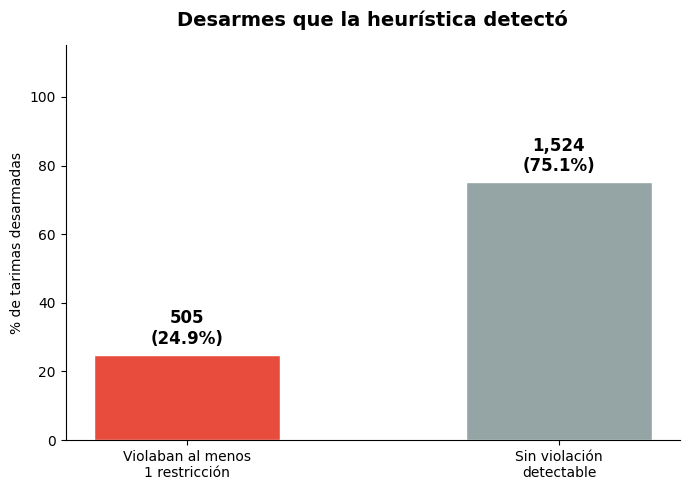

In [28]:
import matplotlib.pyplot as plt

pct_viola    = tarimas_desarmadas["viola_alguna"].mean() * 100
pct_no_viola = (1 - tarimas_desarmadas["viola_alguna"].mean()) * 100
n_viola    = tarimas_desarmadas["viola_alguna"].sum()
n_no_viola = (~tarimas_desarmadas["viola_alguna"]).sum()

fig, ax = plt.subplots(figsize=(7, 5))
categorias = ["Violaban al menos\n1 restricción", "Sin violación\ndetectable"]
valores    = [pct_viola, pct_no_viola]
conteos    = [n_viola, n_no_viola]
colores    = ["#e74c3c", "#95a5a6"]

bars = ax.bar(categorias, valores, color=colores, width=0.5, edgecolor="white")
ax.set_title("Desarmes que la heurística detectó", fontsize=14, fontweight="bold", pad=14)
ax.set_ylabel("% de tarimas desarmadas")
ax.set_ylim(0, 115)
ax.spines[["top", "right"]].set_visible(False)

for bar, val, n in zip(bars, valores, conteos):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{n:,}\n({val:.1f}%)", ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

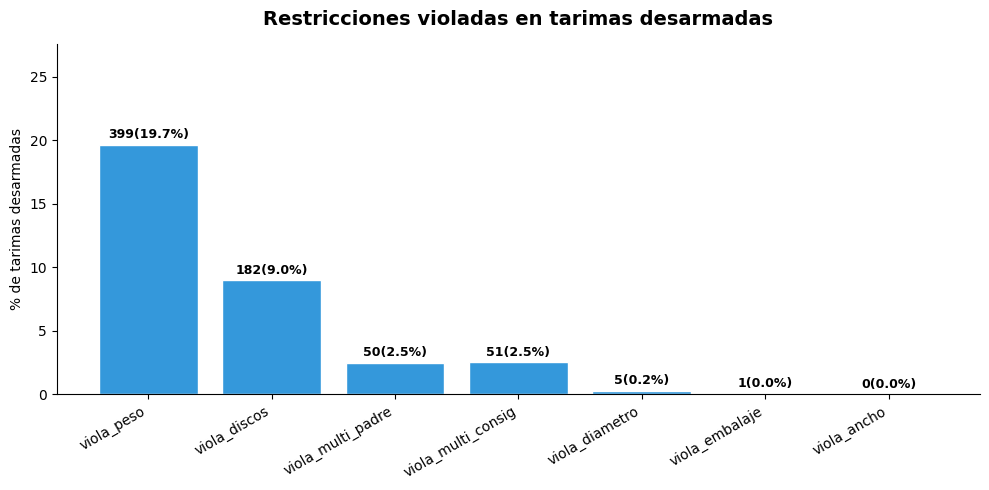

In [30]:
restricciones = [
    "viola_peso", "viola_discos", "viola_multi_padre",
    "viola_multi_consig", "viola_diametro", "viola_embalaje", "viola_ancho"
]

valores  = [tarimas_desarmadas[r].mean() * 100 for r in restricciones]
conteos  = [int(tarimas_desarmadas[r].sum()) for r in restricciones]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(restricciones, valores, color="#3498db", edgecolor="white")
ax.set_title("Restricciones violadas en tarimas desarmadas", fontsize=14, fontweight="bold", pad=14)
ax.set_ylabel("% de tarimas desarmadas")
ax.set_xticks(range(len(restricciones)))
ax.set_xticklabels(restricciones, rotation=30, ha="right")
ax.set_ylim(0, max(valores) * 1.3 + 2)
ax.spines[["top", "right"]].set_visible(False)

for bar, val, n in zip(bars, valores, conteos):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f"{n:,}({val:.1f}%)", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()